Supplementary Material:

Experimental Determination of Selected Thermophysical Properties of 2-Methylfuran + Ethanol Binary Mixture by Ariel Hernández, Melissa Morales, Marcela Cartes, Andrés Mejía. Submitted to Journal of Chemical & Engineering Data 2025

This notebook is used for routine VLE calculations of experimental data:

The modified Raoult law is used to calculate the experimental activity coefficients and Excess Gibbs energy.  

The point-point consistency test based on the $\gamma - \phi$ of Fredenslund et al., approach is used to validate the data.

Selected activity coefficient models (i.e., Porter, Margules, Wilson, NRTL, and UNIQUAC) are parameterized.


In [1]:
#Fitting Antoine Coefficients & V_Rackett
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Fit Antoine parameters
def psat_obj(C, Pexp, Texp, base = 'log'):
    if base == 'ln':
       pant = np.exp(C[0]-C[1]/(Texp+C[2]))
    elif base == 'log':
       pant = 10**(C[0]-C[1]/(Texp+C[2]))
    error = np.sum((pant/Pexp - 1)**2)
    return error

def fit_ant(Texp, Pexp, x0=[0, 0, 0], base='log'):
    fit = minimize(psat_obj, x0, args=(Pexp, Texp, base))
    return fit

# Calculate saturation pressure (in kPa) at given saturation temperature (in K) using fitted parameters
def psat(t,y,base='log'):
    if base == 'log':
        res= (10**(y[0]-y[1]/(t+y[2])))
    elif base == 'ln':
        res= (np.exp(y[0]-y[1]/(t+y[2])))
    return res
# Calculate saturation temperature (in K) at given saturation pressure (in kPa) using fitted parameters
def tsat(p,y, base ='log'):
    if base == 'log':
       res = -y[2]+y[1]/(y[0]-np.log10(p))
    elif base == 'ln':
       res = -y[2]+y[1]/(y[0]-np.log(p)) 
    return res  

In [2]:
class component:
    def __init__(self, name='None', Tc=0, Pc=0, Zc=0, Vc=0, w=0, mupol=0, Rg=0, eta=0, 
                 a=0, b=0, cii=0, Ant=[0, 0, 0], Mw=1., ri=0., qi=0. , qqi=0.):
        R = 83.14
        self.name = name
        self.Tc = Tc  # critical temperature in K
        self.Pc = Pc  # critical pressure in bar
        self.Zc = Zc  # critical compressibility factor
        self.Vc = Vc  # critical volume in cm3/mol
        if Vc == 0 and Zc != 0:
            self.Vc = R*Zc*Tc/Pc
        elif Vc != 0 and Zc == 0:
            self.Zc = Pc*Vc/(R*Tc)
        self.w = w  # acentric factor
        self.mupol = mupol  # dipole moment in Debye
        self.Rg = Rg  # mean radius of gyration in Angstrom
        self.eta = eta  # association parameter in Hayden and O'Connell's method
        self.Ant = Ant  # Antoine coefficeint, base e = 2.71
        self.a = a  # a parameter in Tsonopoulos correlation
        self.b = b  # b parameter in Tsonopoulos correlation
        self.nc = 1
        self.Mw = Mw  # Molar weight in g/mol
        self.ri = ri  # molecular volume for UNIQUAC model
        self.qi = qi  # molecular surface for UNIQUAC model
        self.qqi = qqi  # molecular surface for UNIQUAC model for water and alcohols
        if qqi == 0:
            self.qqi = qi

class mixture(object):
    def __init__(self, component1, component2):
        self.names = [component1.name, component2.name]
        self.Tc = [component1.Tc, component2.Tc]
        self.Pc = [component1.Pc, component2.Pc]
        self.Zc = [component1.Zc, component2.Zc]
        self.w = [component1.w, component2.w]
        self.mupol = [component1.mupol, component2.mupol]
        self.Rg = [component1.Rg, component2.Rg]
        self.eta = [component1.eta, component2.eta]
        self.Ant = [component1.Ant, component2.Ant]
        self.a = [component1.a, component2.a]
        self.b = [component1.b, component2.b]
        self.Vc = [component1.Vc, component2.Vc]
        self.nc = 2
        self.Mw = [component1.Mw,  component2.Mw]
        self.ri = [component1.ri, component2.ri]
        self.qi = [component1.qi, component2.qi]
        self.qqi = [component1.qqi, component2.qqi]

    def psat(self, T):
        """
        This subroutine calculates the vapor pressure according to Antoine equation:
    
        vl = v_c*Z_c^{(1-T_r)^{2/7}}`

        Units:
        --------------------------------------------------------------------------------------
        T = (float) absolute temperature [K]
        vl0 = (array_like) saturated liquid volume of each component [cm3*mol-1]
        --------------------------------------------------------------------------------------
        """
        coef = np.vstack(self.Ant)
        return 10**(coef[:,0]-coef[:,1]/(T+coef[:,2]))/100
    
    def vlrackett(self, T):
        """
        This subroutine calculates the saturated liquid volume according to Rackett equation:
    
        vl = v_c*Z_c^{(1-T_r)^{2/7}}`

        Units:
        --------------------------------------------------------------------------------------
        T = (float) absolute temperature [K]
        vl0 = (array_like) saturated liquid volume of each component [cm3*mol-1]
        --------------------------------------------------------------------------------------
        """
        Tc = np.array(self.Tc)
        Vc = np.array(self.Vc)
        Zc = np.array(self.Zc)
        Tr = T/Tc
        vl0 = Vc*Zc**((1-Tr)**(2/7))
        
        return vl0

def acentric(component):
    """
    This subroutine calculates the acentric factor by definition:
    
    w = -log10(psat(Tr=0.7)/Pc)-1
    
    """
    import math
    T = component.Tc*0.7
    p = component.psat(T)
    w = -math.log10(p/component.Pc)-1
    return w

In [3]:
def Hayden(mix, T, matrix_eta):
    """
    This subroutine estimates the second virial coefficients according to the Hayden-O'Connell method.
    """
    Tc = np.asarray(mix.Tc)
    Pc = np.asarray(mix.Pc)
    Vc = np.asarray(mix.Vc)
    Rg = np.asarray(mix.Rg)
    mupol = np.asarray(mix.mupol)
    eta = np.asarray(mix.eta)
    c = len(mupol)
    wm = np.zeros(c)
    ek0 = np.zeros(c)
    ek = np.zeros(c)
    sigma03 = np.zeros(c)
    sigma3 = np.zeros(c)
    mupolr = np.zeros(c)
    mupolrr = np.zeros(c)
    for i in range(c):
        wm[i] = 0.006*Rg[i]+0.02087*Rg[i]**2-0.00136*Rg[i]**3
        ek0[i] = Tc[i]*(0.748+0.91*wm[i]-0.4*eta[i]/(2+20*wm[i]))
        sigma03[i] = (2.44-wm[i])**3*Tc[i]/(Pc[i]/1.013)
        if mupol[i] < 1.45:
            ek[i] = ek0[i]
            sigma3[i] = sigma03[i]
        else:
            C = 2.882-1.882*wm[i]/(0.03+wm[i])
            xi = mupol[i]**4/(5.723e-08*C*ek0[i]*sigma03[i]**2*Tc[i])
            n = 16+400*wm[i]
            ek[i] = ek0[i]/(1+xi)**(n/(n-6))
            sigma3[i] = sigma03[i]*(1+xi)**(3/(n-6))
    
    wmij = np.add.outer(wm, wm)/2   
    ekij = 0.7*np.sqrt(np.outer(ek, ek))+0.6/(np.add.outer(1/ek, 1/ek))
    sigma3ij = np.sqrt(np.outer(sigma3, sigma3))
    mupolrij = 7243.8*np.outer(mupol, mupol)/ekij/sigma3ij
    mupolrrij = np.zeros_like(mupolrij)
    for i in range(c):
        for j in range(c):
            if mupol[i] > 1.45:
                if mupolrij[i,j] >= 0.25:
                    mupolrrij[i,j] = mupolrij[i,j]-0.25
                elif mupolrij[i,j] >= 0.04:
                    mupolrrij[i,j] = 0
                else:
                    mupolrrij[i,j] = mupolrij[i,j]
            else:
                mupolrrij[i,j] = 0
            
    A = -0.3-0.05*mupolrij
    dH = 1.99+0.2*mupolrij**2
    b0 = 1.2618*sigma3ij
    invTrij = ekij/T-1.6*wmij
    Bnpij = b0*(0.94-1.47*invTrij-0.85*invTrij**2+1.015*invTrij**3)
    Bpij = -b0*mupolrrij*(0.75-3*invTrij+2.1*invTrij**2+2.1*invTrij**3)
    Bmbij = b0*A*np.exp(dH/T*ekij)
    Bcij = b0*np.exp(matrix_eta*(650/(ek+300)-4.27))*(1-np.exp(1500*matrix_eta/T))
    Bij = Bnpij+Bpij+Bmbij+Bcij
    
    return Bij

def atson(component, group):
    '''
    calculate Tsonopoulos' "a" parameter according to an empirical correlation given for a specific functional group.
    Parameters
    ----------------------------------
    component
    group: functional group (ketone, aldehyde, alkyl_nitrile, ether, ester, alkyl_halide, mercaptan, sulfide, disulfide)
    
    '''
    mupolr = 0.9869e05*component.mupol**2*component.Pc/component.Tc**2
    if group=='ketone' or group=='aldehyde' or group=='alkyl_nitrile' or group=='ether' or group=='ester':
        a = -2.14e-04*mupolr-4.308e-21*mupolr**8
    elif group=='alkyl_halide' or group=='mercaptan' or group=='sulfide' or group=='disulfide':
        a = -2.188e-11*mupolr**4-7.831e-21*mupolr**8
    else:
        print('No correlation for a')
    return a

def Tsonopoulos(mix, T, kij):
    """
    This subroutine estimates the second virial coefficients according to Tsonopoulos' method.
    """
    Tc = np.asarray(mix.Tc)
    Pc = np.asarray(mix.Pc)
    Vc = np.asarray(mix.Vc)
    w = np.asarray(mix.w)
    a = np.asarray(mix.a)
    b = np.asarray(mix.b)
    u = Pc*Vc/Tc
    
    Vc3 = Vc**(1/3)
    Tcij = np.sqrt(np.outer(Tc, Tc))*(1-kij)
    Pcij = 4*Tcij*(np.add.outer(u, u))/(np.add.outer(Vc3, Vc3))**3
    wij = np.add.outer(w, w)/2
    aij = np.add.outer(a, a)/2
    bij = np.add.outer(b, b)/2 
    Tr = T/Tcij
    f0 = 0.1445-0.330/Tr-0.1385/Tr**2-0.0121/Tr**3-0.000607/Tr**8
    f1 = 0.0637+0.331/Tr**2-0.423/Tr**3-0.008/Tr**8
    f2 = 1/Tr**6
    f3 = -1/Tr**8
    Bij = 83.14*Tcij/Pcij*(f0+wij*f1+aij*f2+bij*f3)
    
    return Bij

In [4]:
def gammma(mix, method, Texp, pexp, Xexp, Yexp):
    """
    ---------------------------------------------------------------------------------------------------------------------
    This subroutine calculates the experimental activity coefficients according to the gamma-phi approach for an array
    of equilibrium data.
    Inputs:
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    method = algorithm for estimating second virial coefficients (Abbott, Tsonopoulos or Hayden). If it is NOT specified, 
    the ideal solution (Raoult's law) is assumed by default.
    Texp = array of temperature, K
    pexp = array of pressure, bar
    Xexp = array of compositions in the liquid phase
    Yexp = array of compositions in the vapor phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    gamma1 = array of activity coeficients for species 1
    gamma2 = array of activity coeficients for species 2
    gE = array of dimensionless excess (molar) Gibbs energy
    gEx = array of reduced dimensionless excess (molar) Gibbs energy
    ---------------------------------------------------------------------------------------------------------------------
    """
    n = len(Texp)
    gamma1 = np.zeros_like(Texp)
    gamma2 = np.zeros_like(Texp)
    gE = np.zeros_like(Texp)
    gEx = np.zeros_like(Texp)
    for i in range(n):
        psat1, psat2 = mix.psat(Texp[i])
        vlsat1, vlsat2 = mix.vlrackett(Texp[i])
        if method == "Ideal":
            gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1
            gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2
        else:
            if method == "Abbott":
                [B11, B12],[B21, B22] = Abbott(mix, Texp[i], etaij)
            elif method == "Tsonopoulos":
                [B11, B12],[B21, B22] = Tsonopoulos(mix, Texp[i], etaij)
            elif method == "Hayden":
                [B11, B12],[B21, B22] = Hayden(mix, Texp[i], etaij)
            else:
                print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
            d12 = 2*B12-B22-B11
            d21 = 2*B21-B11-B22
            gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1*np.exp((B11-vlsat1)*(pexp[i]-psat1)/83.14/Texp[i]+Yexp[1,i]**2*pexp[i]/83.14/Texp[i]*d12)
            gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2*np.exp((B22-vlsat2)*(pexp[i]-psat2)/83.14/Texp[i]+Yexp[0,i]**2*pexp[i]/83.14/Texp[i]*d21)
        
        gE[i] = Xexp[0,i]*np.log(gamma1[i])+Xexp[1,i]*np.log(gamma2[i])
        gEx[i] = gE[i]/Xexp[0,i]/Xexp[1,i]
    
    return gamma1, gamma2, gE, gEx

In [5]:
def Leg(n):
    import sympy as sp
    x = sp.symbols('x')
    '''
    This subroutine writes sums of Legendre's polynomials (from zeroth to fourth order).
    '''
    if n == 0:
        Leg = 1
    elif n == 1:
        Leg = 2*x-1
    elif n == 2:
        Leg = 6*(x**2-x+1/6)
    elif n == 3:
        Leg = 20*(x**3-3/2*x**2+3/5*x-1/20)
    elif n == 4:
        Leg = 70*(x**4-2*x**3+9/7*x**2-2/7*x+1/70)
    else:
        print("Sorry, but we only allow n less than 5.")
    
    return Leg
  
def gE(mixture, model, n=None, T=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    """
    ---------------------------------------------------------------------------------------------------------------------
    This subroutine writes the dimensionless excess Gibbs energy as a function of the composition of the liquid phase.
    model = activity-coefficient model (Legendre, Wilson, NRTL or UNIQUAC)
    n = order in the case of Legendre model
    T = temperature (required for local composition models: Wilson, NRTL or UNIQUAC)
    NOTE: 0.3 is taken as default for alpha12 (non-randomness parameter) in NRTL equation.
    ---------------------------------------------------------------------------------------------------------------------
    """
    if model == "Legendre":
        if n == 0:
            gE = x*(1-x)*a0*Leg(0)
        elif n == 1:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1))
        elif n == 2:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1)+a2*Leg(2))
        elif n == 3:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1)+a2*Leg(2)+a3*Leg(3))
        elif n == 4:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1)+a2*Leg(2)+a3*Leg(3)+a4*Leg(4))
        else:
            print("Sorry, but we only allow n less than 5.")
            
    elif model == "Wilson":
        vl1, vl2 = mixture.vlrackett(T)
        A12 = vl2/vl1*sp.exp(-a0/T)
        A21 = vl1/vl2*sp.exp(-a1/T)
        gE = -x*sp.log(x+A12*(1-x))-(1-x)*sp.log(1-x+A21*x)

    elif model == "NRTL":
        alpha12 = 0.3
        tau12 = a0/T
        tau21 = a1/T
        G12 = sp.exp(-alpha12*tau12)
        G21 = sp.exp(-alpha12*tau21)
        gE = -x*(1-x)*(tau21*G21/(x+(1-x)*G21)+tau12*G12/(1-x+x*G12))
        
    elif model == "UNIQUAC":
        import math
        r1, r2 = mixture.ri
        q1, q2 = mixture.qi
        qq1, qq2 = mixture.qqi
        Fi1 = x*r1/(x*r1+(1-x)*r2)
        Fi2 = 1-Fi1
        thet1 = x*q1/(x*q1+(1-x)*q2)
        thet2 = 1-thet1
        theta1 = x*qq1/(x*qq1+(1-x)*qq2)
        theta2 = 1-theta1
        tau12 = sp.exp(-a0/T)
        tau21 = sp.exp(-a1/T)
        gEc = x*sp.log(Fi1/x)+(1-x)*sp.log(Fi2/(1-x))+5*(x*q1*sp.log(thet1/Fi1)+(1-x)*q2*sp.log(thet2/Fi2))
        gEr = -x*qq1*sp.log(theta1+theta2*tau21)-(1-x)*qq2*sp.log(theta2+theta1*tau12)
        gE = gEc+gEr
         
    else:
        print("Sorry, but this activity-coefficient model was not implemented. Please, choose between Legendre, Wilson, NRTL and UNIQUAC.")

    return gE

def dgE(mixture, model, n=None, T=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    dgE = sp.diff(gE(mixture, model, n, T), x)
    return dgE

def VLEgamphi_obj(A, mixture, model, method, Texp, pexp, Xexp, Yexp, n=None, mixij=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    R = 83.14
    s = len(Texp)
    psat1 = np.zeros(s)
    psat2 = np.zeros(s)
    vlsat1 = np.zeros(s)
    vlsat2 = np.zeros(s)
    B11 = np.zeros(s)
    B22 = np.zeros(s)
    B12 = np.zeros(s)
    B21 = np.zeros(s)
    d12 = np.zeros(s)
    d21 = np.zeros(s)
    Bp1 = np.zeros(s)
    Bp2 = np.zeros(s)
    gamma1 = np.zeros(s)
    gamma2 = np.zeros(s)
    phi1 = np.zeros(s)
    phi2 = np.zeros(s)
    phisat1 = np.zeros(s)
    phisat2 = np.zeros(s)
    zeta1 = np.zeros(s)
    zeta2 = np.zeros(s)
    F1 = np.zeros(s)
    F2 = np.zeros(s)
    p = np.zeros(s)
    y1 = np.zeros(s)
    for i in range(s):
        gExc = gE(mixture, model, n, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: A[0], a1: A[1], a2: A[2], a3: A[3], a4: A[4]})
        dgExc = dgE(mixture, model, n, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: A[0], a1: A[1], a2: A[2], a3: A[3], a4: A[4]})
        gamma1[i] = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
        gamma2[i] = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
        psat1[i], psat2[i] = mixture.psat(Texp[i])
        if method=="Ideal":
            p[i] = Xexp[0,i]*gamma1[i]*psat1[i]+Xexp[1,i]*gamma2[i]*psat2[i]
            y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/p[i] 
        else:
            p0 = pexp[i]
            y10 = Yexp[0,i]
            vlsat1[i], vlsat2[i] = mixture.vlrackett(Texp[i])
            if method=="Abbott":
                [B11[i], B12[i]],[B21[i], B22[i]] = Abbott(mix, Texp[i], etaij)
            elif method=="Tsonopoulos":
                [B11[i], B12[i]],[B21[i], B22[i]] = Tsonopoulos(mix, Texp[i], etaij)
            elif method=="Hayden":
                [B11[i], B12[i]],[B21[i], B22[i]] = Hayden(mix, Texp[i], etaij)
            else:
                print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
            
            d12[i] = 2*B12[i]-B11[i]-B22[i]
            d21[i] = 2*B21[i]-B11[i]-B22[i]
            Bp1[i] = B11[i]+(1-y10)**2*d12[i]
            Bp2[i] = B22[i]+y10**2*d21[i]
            phi1[i] = np.exp(Bp1[i]*p0/R/Texp[i])
            phi2[i] = np.exp(Bp2[i]*p0/R/Texp[i])
            phisat1[i] = np.exp(B11[i]*psat1[i]/R/Texp[i])
            phisat2[i] = np.exp(B22[i]*psat2[i]/R/Texp[i])
            zeta1[i] = np.exp(vlsat1[i]*(p0-psat1[i])/R/Texp[i])
            zeta2[i] = np.exp(vlsat2[i]*(p0-psat2[i])/R/Texp[i])
            F1[i] = phi1[i]/phisat1[i]/zeta1[i]
            F2[i] = phi2[i]/phisat2[i]/zeta2[i]
            p[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]+Xexp[1,i]*gamma2[i]*psat2[i]/F2[i]
            y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]/p[i]
            while abs(p[i]-p0)>=1.0e-08 and abs(y1[i]-y10)>=1.0e-08:
                p0 = p[i]
                y10 = y1[i]
                Bp1[i] = B11[i]+(1-y10)**2*d12[i]
                Bp2[i] = B22[i]+y10**2*d21[i]
                phi1[i] = np.exp(Bp1[i]*p0/R/Texp[i])
                phi2[i] = np.exp(Bp2[i]*p0/R/Texp[i])
                zeta1[i] = np.exp(vlsat1[i]*(p0-psat1[i])/R/Texp[i])
                zeta2[i] = np.exp(vlsat2[i]*(p0-psat2[i])/R/Texp[i])
                F1[i] = phi1[i]/phisat1[i]/zeta1[i]
                F2[i] = phi2[i]/phisat2[i]/zeta2[i]
                p[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]+Xexp[1,i]*gamma2[i]*psat2[i]/F2[i]
                y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]/p[i]

    objfun = np.sum((p/pexp-1)**2+(y1-Yexp[0])**2)
    
    return objfun

def VLEgamphi(mixture, model, method, Texp, pexp, Xexp, Yexp, mixij=None, A0=[0, 0, 0, 0, 0]):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    s = len(Texp)
    from scipy.optimize import minimize
    if model == "Legendre":
        print("********************************************************************************")
        print("                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     ")
        print("********************************************************************************")
        gamma1 = np.zeros((5,s))
        gamma2 = np.zeros((5,s))
        p = np.zeros((5,s))
        y1 = np.zeros((5,s))
        dp = np.zeros((5,s))
        dy1 = np.zeros((5,s))
        dewp = np.zeros((5,s))
        dewx1 = np.zeros((5,s))
        dewgamma1 = np.zeros((5,s))
        dewgamma2 = np.zeros((5,s))
        dewdp = np.zeros((5,s))
        dewdx1 = np.zeros((5,s))
        for k in range(5):
            n = k
            sol = minimize(VLEgamphi_obj, A0, args=(mixture, model, method, Texp, pexp, Xexp, Yexp, n, mixij), method='SLSQP')
            params = sol.x
            for i in range(s):
                gExc = gE(mixture, model, n=k).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                dgExc = dgE(mixture, model, n=k).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                gamma1[k,i] = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
                gamma2[k,i] = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
                x10 = Xexp[0,i]
                dewgExc = gE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                dewdgExc = dgE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                dewgamma1[k,i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                dewgamma2[k,i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                psat1, psat2 = mixture.psat(Texp[i])
                if method == "Ideal":
                    "********************************************************************************************"
                    "BUBBLE-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    p[k,i] = Xexp[0,i]*gamma1[k,i]*psat1+Xexp[1,i]*gamma2[k,i]*psat2
                    y1[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/p[k,i]
                
                    "********************************************************************************************"
                    "DEW-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    x10 = Xexp[0,i]
                    dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((dewgamma2[k,i]*psat2-dewgamma1[k,i]*psat1)*Yexp[0,i]+psat1*dewgamma1[k,i])
                    dewx1[k,i] = Yexp[0,i]*dewp[k,i]/dewgamma1[k,i]/psat1
                    while abs(dewx1[k,i]-x10)>=1.0e-08:
                        x10 = dewx1[k,i]
                        dewgExc = gE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewdgExc = dgE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewgamma1[k,i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                        dewgamma2[k,i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                        dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((dewgamma2[k,i]*psat2-dewgamma1[k,i]*psat1)*Yexp[0,i]+psat1*dewgamma1[k,i])
                        dewx1[k,i] = Yexp[0,i]*dewp[k,i]/dewgamma1[k,i]/psat1
            
                else:
                    vlsat1, vlsat2 = mixture.vlrackett(Texp[i])
                    if method == "Abbott":
                        [B11, B12],[B21, B22] = Abbott(mix, Texp[i], etaij)
                    elif method == "Tsonopoulos":
                        [B11, B12],[B21, B22] = Tsonopoulos(mix, Texp[i], etaij)
                    elif method == "Hayden":
                        [B11, B12],[B21, B22] = Hayden(mix, Texp[i], etaij)
                    else:
                        print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
                    d12 = 2*B12-B11-B22
                    d21 = 2*B21-B11-B22
                    phisat1 = np.exp(B11*psat1/R/Texp[i])
                    phisat2 = np.exp(B22*psat2/R/Texp[i])
                    "********************************************************************************************"
                    "BUBBLE-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    p0 = pexp[i]
                    y10 = Yexp[0,i]
                    Bp1 = B11+(1-y10)**2*d12
                    Bp2 = B22+y10**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    p[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1+Xexp[1,i]*gamma2[k,i]*psat2/F2
                    y1[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1/p[k,i]
                    while abs(p[k,i]-p0)>=1.0e-08 and abs(y1[k,i]-y10)>=1.0e-08:
                        p0 = p[k,i]
                        y10 = y1[k,i]
                        Bp1 = B11+(1-y10)**2*d12
                        Bp2 = B22+y10**2*d21
                        phi1 = np.exp(Bp1*p0/R/Texp[i])
                        phi2 = np.exp(Bp2*p0/R/Texp[i])
                        zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                        zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                        F1 = phi1/phisat1/zeta1
                        F2 = phi2/phisat2/zeta2
                        p[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1+Xexp[1,i]*gamma2[k,i]*psat2/F2
                        y1[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1/p[k,i]
                    "********************************************************************************************"
                    "DEW-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    p0 = pexp[i]
                    Bp1 = B11+Yexp[1,i]**2*d12
                    Bp2 = B22+Yexp[0,i]**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((F1*dewgamma2[k,i]*psat2-F2*dewgamma1[k,i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[k,i])
                    dewx1[k,i] = Yexp[0,i]*F1*dewp[k,i]/dewgamma1[k,i]/psat1
                    while abs(dewp[k,i]-p0)>=1.0e-08 and abs(dewx1[k,i]-x10)>=1.0e-08:
                        x10 = dewx1[k,i]
                        p0 = dewp[k,i]
                        Bp1 = B11+Yexp[1,i]**2*d12
                        Bp2 = B22+Yexp[0,i]**2*d21
                        phi1 = np.exp(Bp1*p0/R/Texp[i])
                        phi2 = np.exp(Bp2*p0/R/Texp[i])
                        F1 = phi1/phisat1/zeta1
                        F2 = phi2/phisat2/zeta2
                        zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                        zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                        dewgExc = gE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewdgExc = dgE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewgamma1[k,i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                        dewgamma2[k,i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                        dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((F1*dewgamma2[k,i]*psat2-F2*dewgamma1[k,i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[k,i])
                        dewx1[k,i] = Yexp[0,i]*F1*dewp[k,i]/dewgamma1[k,i]/psat1
            
            "********************************************************************************************"
            "CALCULATION OF BUBBLE-POINT DEVIATION STATISTICS:"
            "********************************************************************************************"   
            dp[k] = 100*(p[k]-pexp)
            dy1[k] = y1[k]-Yexp[0]
            AADp = 1/len(pexp)*np.sum(abs(100*(p[k]-pexp)))
            AADy1 = 1/len(Yexp[0])*np.sum(abs(y1[k]-Yexp[0]))
            "********************************************************************************************"
            "CALCULATION OF DEW-POINT DEVIATION STATISTICS:"
            "********************************************************************************************"
            dewdp[k] = 100*(dewp[k]-pexp)
            dewdx1[k] = dewx1[k]-Xexp[0]
            dewAADp = 1/len(pexp)*np.sum(abs(100*(dewp[k]-pexp)))
            dewAADx1 = 1/len(Xexp[0])*np.sum(abs(dewx1[k]-Xexp[0]))
            
            print("p/kPa =", pexp[0]*100)
            print("N =", k)
            print("------------------------------------------")
            print("Coefficients of Legendre polynomials:")
            print("------------------------------------------")
            print("A0 =", params[0])
            print("A1 =", params[1])
            print("A2 =", params[2])
            print("A3 =", params[3])
            print("A4 =", params[4])
            print("------------------------------------------")
            print("Bubble-point statistics:")
            print("------------------------------------------")
            print("AAD(p)/kPa =", AADp)
            print("AAD(y1) =", AADy1)
            print("------------------------------------------")
            print("Dew-point statistics:")
            print("------------------------------------------")
            print("AAD(p)/kPa =", dewAADp)
            print("AAD(x1) =", dewAADx1)
            print("------------------------------------------")

            import matplotlib.pyplot as plt
            plt.rc('text', usetex=False )
            plt.rc('font', family="Times New Roman", weight='normal', size=10)
            plt.rcParams['mathtext.fontset'] = 'custom'
            plt.rcParams['mathtext.rm'] = 'Times New Roman'
            plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
            plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
    
            fig = plt.figure(figsize=(5,5))
            plt.scatter(Xexp[0], dp[k], color='black', clip_on=False, zorder=10)
            plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=-1.0, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=1.0, linestyle='dashed', color='black', linewidth=0.5)
            plt.xlim([0, 1])
            plt.xlabel(r"$x_{1}$")
            plt.ylabel(r"$\delta p_{1}$")
            plt.show()

            fig = plt.figure(figsize=(5,5))
            plt.scatter(Xexp[0], dy1[k], color='black', clip_on=False, zorder=10)
            plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=-0.01, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=0.01, linestyle='dashed', color='black', linewidth=0.5)
            plt.xlim([0, 1])
            plt.xlabel(r"$x_{1}$")
            plt.ylabel(r"$\delta y_{1}$")
            plt.show()

    else:
        print("********************************************************************************")
        print("           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              ")
        print("********************************************************************************")
        params = np.zeros(5)
        gamma1 = np.zeros(s)
        gamma2 = np.zeros(s)
        dewgamma1 = np.zeros(s)
        dewgamma2 = np.zeros(s)
        p = np.zeros(s)
        y1 = np.zeros(s)
        dewp = np.zeros(s)
        dewx1 = np.zeros(s)
        sol = minimize(VLEgamphi_obj, A0, args=(mixture, model, method, Texp, pexp, Xexp, Yexp, mixij), method='SLSQP')
        params = sol.x
        for i in range(s):
            gExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            dgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            gamma1[i] = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
            gamma2[i] = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
            x10 = Xexp[0,i]
            dewgExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            dewdgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            dewgamma1[i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
            dewgamma2[i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
            psat1, psat2 = mixture.psat(Texp[i])                
            if method=="Ideal":
                "********************************************************************************************"
                "BUBBLE-POINT CALCULATIONS:"
                "********************************************************************************************"
                p[i] = Xexp[0,i]*gamma1[i]*psat1+Xexp[1,i]*gamma2[i]*psat2
                y1[i] = Xexp[0,i]*gamma1[i]*psat1/p[i]
                
                "********************************************************************************************"
                "DEW-POINT CALCULATIONS:"
                "********************************************************************************************"
                dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((dewgamma2[i]*psat2-dewgamma1[i]*psat1)*Yexp[0,i]+psat1*dewgamma1[i])
                dewx1[i] = Yexp[0,i]*dewp[i]/dewgamma1[i]/psat1
                while abs(dewx1[i]-x10)>=1.0e-08:
                    x10 = dewx1[i]
                    dewgExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewdgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewgamma1[i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                    dewgamma2[i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                    dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((dewgamma2[i]*psat2-dewgamma1[i]*psat1)*Yexp[0,i]+psat1*dewgamma1[i])
                    dewx1[i] = Yexp[0,i]*dewp[i]/dewgamma1[i]/psat1
                        
            else:
                vlsat1, vlsat2 = mixture.vlrackett(Texp[i])
                if method=="Abbott":
                    [B11, B12],[B21, B22] = Abbott(mix, Texp[i], etaij)
                elif method=="Tsonopoulos":
                    [B11, B12],[B21, B22] = Tsonopoulos(mix, Texp[i], etaij)
                elif method=="Hayden":
                    [B11, B12],[B21, B22] = Hayden(mix, Texp[i], etaij)
                else:
                    print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
                d12 = 2*B12-B11-B22
                d21 = 2*B21-B11-B22
                phisat1 = np.exp(B11*psat1/R/Texp[i])
                phisat2 = np.exp(B22*psat2/R/Texp[i])
                "********************************************************************************************"
                "BUBBLE-POINT CALCULATIONS:"
                "********************************************************************************************"
                p0 = pexp[i]
                y10 = Yexp[0,i]
                Bp1 = B11+(1-y10)**2*d12
                Bp2 = B22+y10**2*d21
                phi1 = np.exp(Bp1*p0/R/Texp[i])
                phi2 = np.exp(Bp2*p0/R/Texp[i])
                zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                F1 = phi1/phisat1/zeta1
                F2 = phi2/phisat2/zeta2
                p[i] = Xexp[0,i]*gamma1[i]*psat1/F1+Xexp[1,i]*gamma2[i]*psat2/F2
                y1[i] = Xexp[0,i]*gamma1[i]*psat1/F1/p[i]
                while abs(p[i]-p0)>=1.0e-08 and abs(y1[i]-y10)>=1.0e-08:
                    p0 = p[i]
                    y10 = y1[i]
                    Bp1 = B11+(1-y10)**2*d12
                    Bp2 = B22+y10**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    p[i] = Xexp[0,i]*gamma1[i]*psat1/F1+Xexp[1,i]*gamma2[i]*psat2/F2
                    y1[i] = Xexp[0,i]*gamma1[i]*psat1/F1/p[i]
                "********************************************************************************************"
                "DEW-POINT CALCULATIONS:"
                "********************************************************************************************"
                p0 = pexp[i]
                Bp1 = B11+Yexp[1,i]**2*d12
                Bp2 = B22+Yexp[0,i]**2*d21
                phi1 = np.exp(Bp1*p0/R/Texp[i])
                phi2 = np.exp(Bp2*p0/R/Texp[i])
                zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                F1 = phi1/phisat1/zeta1
                F2 = phi2/phisat2/zeta2
                dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((F1*dewgamma2[i]*psat2-F2*dewgamma1[i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[i])
                dewx1[i] = Yexp[0,i]*F1*dewp[i]/dewgamma1[i]/psat1
                while abs(dewp[i]-p0)>=1.0e-08 and abs(dewx1[i]-x10)>=1.0e-08:
                    p0 = dewp[i]
                    x10 = dewx1[i]
                    Bp1 = B11+Yexp[1,i]**2*d12
                    Bp2 = B22+Yexp[0,i]**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    dewgExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewdgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewgamma1[i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                    dewgamma2[i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                    dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((F1*dewgamma2[i]*psat2-F2*dewgamma1[i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[i])
                    dewx1[i] = Yexp[0,i]*F1*dewp[i]/dewgamma1[i]/psat1

        "********************************************************************************************"
        "CALCULATION OF BUBBLE-POINT DEVIATION STATISTICS:"
        "********************************************************************************************"  
        dp = 100*(p-pexp)
        dy1 = y1-Yexp[0]
        AADp = 1/len(pexp)*np.sum(abs(100*(p-pexp)))
        AADy1 = 1/len(Yexp[0])*np.sum(abs(y1-Yexp[0]))
        "********************************************************************************************"
        "CALCULATION OF DEW-POINT DEVIATION STATISTICS:"
        "********************************************************************************************"
        dewdp = 100*(dewp-pexp)
        dewdx1 = dewx1-Xexp[0]
        dewAADp = 1/len(pexp)*np.sum(abs(100*(dewp-pexp)))
        dewAADx1 = 1/len(Xexp[0])*np.sum(abs(dewx1-Xexp[0]))
        
        print("p/kPa =", pexp[0]*100)
        print("Model =", model)
        print("Method =", method)
        print("------------------------------------------")
        print("Energy difference parameters:")
        print("------------------------------------------")
        print("de12 =", params[0])
        print("de21 =", params[1])
        print("------------------------------------------")
        print("Bubble-point calculations:")
        print("------------------------------------------")
        print("AAD(p)/kPa =", AADp)
        print("AAD(y1) =", AADy1)
        print("------------------------------------------")
        print("Dew-point calculations:")
        print("------------------------------------------")
        print("AAD(p)/kPa =", dewAADp)
        print("AAD(x1) =", dewAADx1)
        print("------------------------------------------")


In [6]:
def Tybubble_fobj(Tb, mixture, params, model, method, p, z, n=None, mixij=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    gExc = gE(mixture, model, n=n, T=Tb[0]).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    dgExc = dgE(mixture, model, n=n, T=Tb[0]).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    gamma2 = np.exp(float(gExc)-z*float(dgExc))
    psat1, psat2 = mixture.psat(Tb[0])
    if method == "Ideal":
        bubp = z*psat1*gamma1+(1-z)*psat2*gamma2
        buby1 = z*gamma1*psat1/bubp
    else:
        vlsat1, vlsat2 = mixture.vlrackett(Tb[0])
        if method == "Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, Tb[0], mixij)
        elif method == "Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, Tb[0], mixij)
        elif method == "Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, Tb[0], mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        y10 = z
        Bp1 = B11+(1-y10)**2*d12
        Bp2 = B22+y10**2*d21
        phi1 = np.exp(Bp1*p0/83.14/Tb[0])
        phi2 = np.exp(Bp2*p0/83.14/Tb[0])
        phisat1 = np.exp(B11*psat1/83.14/Tb[0])
        phisat2 = np.exp(B22*psat2/83.14/Tb[0])
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/Tb[0])
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/Tb[0])
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
        buby1 = z*gamma1*psat1/F1/bubbp
        while abs(buby1-y10)>=1.0e-08:
            y10 = buby1
            Bp1 = B11+(1-y10)**2*d12
            Bp2 = B22+y10**2*d21
            phi1 = np.exp(Bp1*p0/83.14/Tb[0])
            phi2 = np.exp(Bp2*p0/83.14/Tb[0])
            phisat1 = np.exp(B11*psat1/83.14/Tb[0])
            phisat2 = np.exp(B22*psat2/83.14/Tb[0])
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/Tb[0])
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/Tb[0])
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
            buby1 = z*gamma1*psat1/F1/bubp

    objfun = (bubp/p-1)**2
    
    return objfun

def Tybubble(mixture, params, model, method, p, z, n=None, mixij=None, t0=[0]):
    """
    ---------------------------------------------------------------------------------------------------------------------
    Ty-BUBBLE-POINT CALULATIONS SUBROUTINE:
    This subroutine calculates the bubble temperature (T) and composition of the vapor phase (y) for given values 
    of pressure (p) and composition of the liquid phase (x) according to a gamma-phi model (Legendre, Porter, Margules,
    Wilson, NRTL or UNIQUAC).
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    N = (optional integer) order of the consistency model (0, 1, 2, 3 or 4) in the case of Legendre.
    params = fitting parameters of the gamma-phi model.
    method = gamma-phi solution model (Ideal, Abbott, Tsonopoulos or Hayden).
    mixij = array of mixture parameters of the selected method for estimation of second-virial coefficients
    (if it is TSONOPOULOS, aij and bij, if it is HAYDEN, eta or cross-association parameter).
    Texp = array of temperature, K
    pexp = array of pressure, bar
    Xexp = array of compositions in the liquid phase
    Yexp = array of compositions in the vapor phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    gamma = array of activity coeficients
    gE = array of dimensionless excess (molar) Gibbs energy
    gEx = array of reduced dimensionless excess (molar) Gibbs energy
    ---------------------------------------------------------------------------------------------------------------------
    """
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    from scipy.optimize import minimize
    bubbleT = minimize(Tybubble_fobj, t0, args=(mixture, params, model, method, p, z, n, mixij))
    T = bubbleT.x[0]
    psat1, psat2 = mixture.psat(T)
    gExc = gE(mixture, model, n=n, T=T).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    dgExc = dgE(mixture, model, n=n, T=T).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    gamma2 = np.exp(float(gExc)-z*float(dgExc))
    if method == "Ideal":
        bubp = z*psat1*gamma1+(1-z)*psat2*gamma2
        buby1 = z*gamma1*psat1/bubp
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T)
        if method == "Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T, mixij)
        elif method == "Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T, mixij)
        elif method == "Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        y10 = z
        Bp1 = B11+(1-y10)**2*d12
        Bp2 = B22+y10**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T)
        phi2 = np.exp(Bp2*p0/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        phisat2 = np.exp(B22*psat2/83.14/T)
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
        buby1 = z*gamma1*psat1/F1/bubbp
        while abs(buby1-y10)>=1.0e-08:
            y10 = buby1
            Bp1 = B11+(1-y10)**2*d12
            Bp2 = B22+y10**2*d21
            phi1 = np.exp(Bp1*p0/83.14/T)
            phi2 = np.exp(Bp2*p0/83.14/T)
            phisat1 = np.exp(B11*psat1/83.14/T)
            phisat2 = np.exp(B22*psat2/83.14/T)
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
            buby1 = z*gamma1*psat1/F1/bubp
    
    return T, buby1, gamma1, gamma2, gExc

def Pxdew(mixture, N, params, method, mixij, p0, x10, T, z):
    """
    ---------------------------------------------------------------------------------------------------------------------
    Px-DEW-POINT CALULATIONS SUBROUTINE:
    This subroutine calculates the dew pressure (p) and composition of the liquid phase (x) for given values 
    of temperature (T) and composition of the vapor phase (z) according to a gamma-phi model (Legendre, Porter, Margules,
    Wilson, NRTL or UNIQUAC).
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    N = (optional integer) order of the consistency model (0, 1, 2, 3 or 4) in the case of Legendre.
    params = fitting parameters of the gamma-phi model.
    method = gamma-phi solution model (Ideal, Abbott, Tsonopoulos or Hayden).
    mixij = array of mixture parameters of the selected method for estimation of second-virial coefficients
    (if it is TSONOPOULOS, aij and bij, if it is HAYDEN, eta or cross-association parameter).
    p = guess value of pressure, bar
    T = temperature, K
    z = molar fraction of 1 in the liquid phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    p = bubble-point pressure, bar
    x1 = bubble-point molar fraction of 1 in the liquid phase
    ---------------------------------------------------------------------------------------------------------------------
    """
    gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
    gamma2 = np.exp(float(gExc)-x10*float(dgExc))
    psat1, psat2 = mixture.psat(T)
    if model=="Ideal":
        dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
        dewx1 = z*dewp/gamma1/psat1
        while abs(dewx1-x10)>=1.0e-08:
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
            dewx1 = z*dewp/gamma1/psat1
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T)
        if model=="Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T, mixij)
        elif model=="Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T, mixij)
        elif model=="Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        Bp1 = B11+(1-z)**2*d12
        Bp2 = B22+z**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T)
        phi2 = np.exp(Bp2*p0/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        phisat2 = np.exp(B22*psat2/83.14/T)
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
        while abs(dewp-p0)>=1.0e-08 and abs(dewx1-x10)>=1.0e-08:
            p0 = dewp
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            phi1 = np.exp(Bp1*p0/83.14/T)
            phi2 = np.exp(Bp2*p0/83.14/T)
            phisat1 = np.exp(B11*psat1/83.14/T)
            phisat2 = np.exp(B22*psat2/83.14/T)
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
            dewx1 = z*F1*dewp/gamma1/psat1

def Txdew_fobj(T, mixture, N, params, model, mixij, x10, p, z):
    gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
    gamma2 = np.exp(float(gExc)-x10*float(dgExc))
    psat1, psat2 = mixture.psat(T[0])
    if model=="Ideal":
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T[0])
        if model=="Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T[0], mixij)
        elif model=="Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T[0], mixij)
        elif model=="Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T[0], mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        Bp1 = B11+(1-z)**2*d12
        Bp2 = B22+z**2*d21
        phi1 = np.exp(Bp1*p/83.14/T[0])
        phi2 = np.exp(Bp2*p/83.14/T[0])
        phisat1 = np.exp(B11*psat1/83.14/T[0])
        phisat2 = np.exp(B22*psat2/83.14/T[0])
        zeta1 = np.exp(vlsat1*(p-psat1)/83.14/T[0])
        zeta2 = np.exp(vlsat2*(p-psat2)/83.14/T[0])
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
        while abs(dewx1-x10)>=1.0e-08:
            x10 = dewx1
            phi1 = np.exp(Bp1*p/83.14/T[0])
            phi2 = np.exp(Bp2*p/83.14/T[0])
            phisat1 = np.exp(B11*psat1/83.14/T[0])
            phisat2 = np.exp(B22*psat2/83.14/T[0])
            zeta1 = np.exp(vlsat1*(p-psat1)/83.14/T[0])
            zeta2 = np.exp(vlsat2*(p-psat2)/83.14/T[0])
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
            dewx1 = z*F1*dewp/gamma1/psat1

    objfun = (dewp/p-1)**2
    
    return objfun

def Txdew(mixture, N, params, method, mixij, T0, x10, p, z):
    """
    ---------------------------------------------------------------------------------------------------------------------
    Tx-DEW-POINT CALULATIONS SUBROUTINE:
    This subroutine calculates the dew temperature (T) and composition of the liquid phase (x) for given values 
    of pressure (p) and composition of the vapor phase (z) according to a gamma-phi model (Legendre, Porter, Margules,
    Wilson, NRTL or UNIQUAC).
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    N = (optional integer) order of the consistency model (0, 1, 2, 3 or 4) in the case of Legendre.
    params = fitting parameters of the gamma-phi model.
    method = gamma-phi solution model (Ideal, Abbott, Tsonopoulos or Hayden).
    mixij = array of mixture parameters of the selected method for estimation of second-virial coefficients
    (if it is TSONOPOULOS, aij and bij, if it is HAYDEN, eta or cross-association parameter).
    T0 = guess value of (dew-point) temperature, K
    x10 = guess value of (dew-point) molar fraction of 1 in the liquid phase
    p = pressure, bar
    z = molar fraction of 1 in the vapor phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    T = dew-point temperature, K
    x1 = dew-point molar fraction of 1 in the liquid phase
    ---------------------------------------------------------------------------------------------------------------------
    """
    dewT = minimize(Txdew_fobj, t0, args=(mixture, N, params, method, mixij, p, z))
    T = dewT.x[0]
    gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
    gamma2 = np.exp(float(gExc)-x10*float(dgExc))
    psat1, psat2 = mixture.psat(T)
    if model=="Ideal":
        dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
        dewx1 = z*dewp/gamma1/psat1
        while abs(dewx1-x10)>=1.0e-08:
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
            dewx1 = z*dewp/gamma1/psat1
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T)
        if model=="Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T, mixij)
        elif model=="Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T, mixij)
        elif model=="Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        Bp1 = B11+(1-z)**2*d12
        Bp2 = B22+z**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T)
        phi2 = np.exp(Bp2*p0/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        phisat2 = np.exp(B22*psat2/83.14/T)
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
        while abs(dewp-p0)>=1.0e-08 and abs(dewx1-x10)>=1.0e-08:
            p0 = dewp
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            phi1 = np.exp(Bp1*p0/83.14/T)
            phi2 = np.exp(Bp2*p0/83.14/T)
            phisat1 = np.exp(B11*psat1/83.14/T)
            phisat2 = np.exp(B22*psat2/83.14/T)
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
            dewx1 = z*F1*dewp/gamma1/psat1

In [7]:
#define components
import math
MF = component(name = 'MF', Tc = 527.59, Pc = 47.23, Zc = 0.264878359, Vc = 246,  w = 0.2658,   
                Ant=[6.9047, 1640.7417, -1.9236], ri=3.0711, qi=2.384, Rg=0.0, mupol=0.0, Mw=82.102)

ET = component(name = 'ET', Tc = 513.9, Pc = 61.3, Zc = 0.241, Vc= 167, w = 0.643558,
                 Ant = [8.0877, 2123.5788, -2.2165], ri=2.1055, qi=1.972, Rg=2.259, mupol=1.6909, Mw=46.069)
mix = mixture(MF, ET)

In [8]:
#Temperatures in K
Texp50 = np.array([332.48, 328.51, 323.23, 320.58, 319.53, 318.17, 317.11, 316.27, 315.06, 314.49,
                    314.19, 313.93, 313.73, 313.61, 313.53, 313.37, 313.61, 313.97, 314.78])
Texp75 = np.array([341.98, 339.27, 333.82, 330.67, 329.6, 327.28, 326.65, 326.28, 325.25, 324.95,
                    324.57, 324.23, 324.05, 323.95,323.86, 323.81, 324.08, 324.24, 325.68])
Texp94 = np.array([347.09, 343.48, 340, 336.61, 334.55, 334.49, 332.44, 331.78, 331.18, 331,
                    330.6, 330.35, 330.06, 329.92, 329.86, 330, 330.22, 330.57, 332.32])

#molar fraction of liquid phase
Xexp50 = np.array([[0.013, 0.048, 0.115, 0.165, 0.209, 0.251, 0.283, 0.334, 0.405, 0.46,
                     0.515, 0.576, 0.63, 0.686, 0.739, 0.798, 0.852, 0.91, 0.964],
                     [0.987, 0.952, 0.885, 0.835, 0.791, 0.749, 0.717, 0.666, 0.595,
                      0.54, 0.485, 0.424, 0.37, 0.314, 0.261, 0.202, 0.148, 0.09, 0.036 ]])
Xexp75 = np.array([[0.012, 0.039, 0.109, 0.156, 0.201, 0.259, 0.296, 0.345, 0.4, 0.452,
                     0.513, 0.573, 0.628, 0.686, 0.74, 0.8, 0.854, 0.909, 0.964],
                   [0.988, 0.961, 0.891, 0.844, 0.799, 0.741, 0.704, 0.655, 0.6, 0.548,
                    0.487, 0.427, 0.372, 0.314, 0.26, 0.2, 0.146, 0.091, 0.036]])
Xexp94 = np.array([[0.014, 0.047, 0.104, 0.15, 0.196, 0.235, 0.291, 0.333, 0.394, 0.452,
                     0.508, 0.568, 0.628, 0.686, 0.74, 0.796, 0.855, 0.913, 0.965],
                    [0.986, 0.953, 0.896, 0.85, 0.804, 0.765, 0.709, 0.667, 0.606, 0.548,
                     0.492, 0.432, 0.372, 0.314, 0.26, 0.204, 0.145, 0.087, 0.035]])

#molar fraction of vapor phase
Yexp50 = np.array([[0.105, 0.283, 0.473, 0.558, 0.585, 0.622, 0.65, 0.679, 0.709, 0.725, 0.739,
                     0.754, 0.762, 0.773, 0.784, 0.797, 0.813, 0.843, 0.903], 
                    [0.895, 0.717, 0.527, 0.442, 0.415, 0.378, 0.35, 0.321, 0.291, 0.275, 0.261,
                     0.246, 0.238, 0.227, 0.216, 0.203, 0.187, 0.157, 0.097]])
Yexp75 = np.array([[0.104, 0.216, 0.421, 0.504, 0.55, 0.608, 0.632, 0.652, 0.682, 0.702, 0.715,
                     0.731, 0.74, 0.75, 0.763, 0.777, 0.797, 0.832, 0.9],
                    [0.896, 0.784, 0.579, 0.496, 0.45, 0.392, 0.368, 0.348, 0.318, 0.298, 0.285,
                     0.269, 0.26, 0.25, 0.237, 0.223, 0.203, 0.168, 0.1]])
Yexp94 = np.array([[0.088, 0.24, 0.392, 0.472, 0.535, 0.565, 0.61, 0.637, 0.672, 0.682, 0.701,
                     0.712, 0.726, 0.738, 0.751, 0.766, 0.789, 0.829, 0.906],
                    [0.912, 0.76, 0.608, 0.528, 0.465, 0.435, 0.39, 0.363, 0.328, 0.318, 0.299,
                     0.288, 0.274, 0.262, 0.249, 0.234, 0.211, 0.171, 0.094]])


In [9]:
pexp50 = np.array(np.full(len(Texp50),50.01))
pexp75 = np.array(np.full(len(Texp75),75.01))
pexp94 = np.array(np.full(len(Texp94),94.01))

In [10]:
datavle50 = (Xexp50, Yexp50, Texp50, pexp50)
datavle75 = (Xexp75, Yexp75, Texp75, pexp75)
datavle94 = (Xexp94, Yexp94, Texp94, pexp94)

In [11]:
exp50 = gammma(mix, "Ideal", Texp50, pexp50/100, Xexp50, Yexp50)
exp75 = gammma(mix, "Ideal", Texp75, pexp75/100, Xexp75, Yexp75)
exp94 = gammma(mix, "Ideal", Texp94, pexp94/100, Xexp94, Yexp94)

********************************************************************************
                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     
********************************************************************************
p/kPa = 50.01
N = 0
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6106551361977386
A1 = 0.0
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 1.9385737722655467
AAD(y1) = 0.019980695389419115
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 1.5216605835760544
AAD(x1) = 0.0610081514286677
------------------------------------------


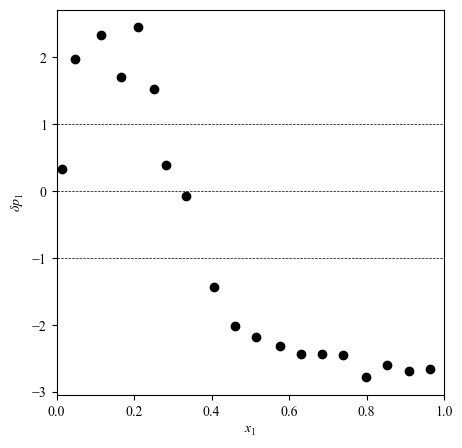

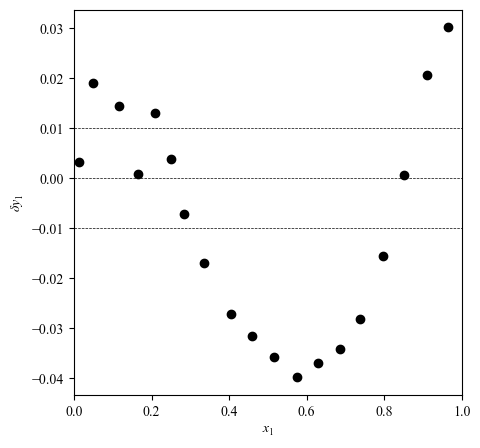

p/kPa = 50.01
N = 1
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6352086110823996
A1 = 0.32524734129345695
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.7847177880747888
AAD(y1) = 0.01249521442210404
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.41678841913347536
AAD(x1) = 0.03290684222723953
------------------------------------------


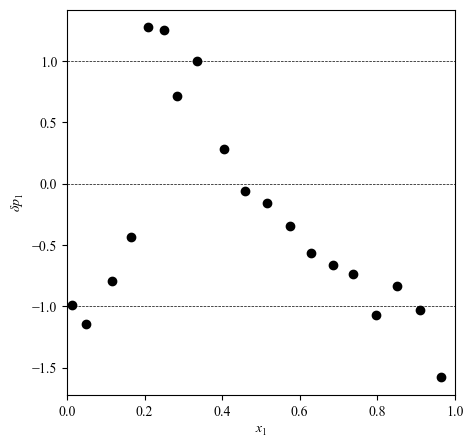

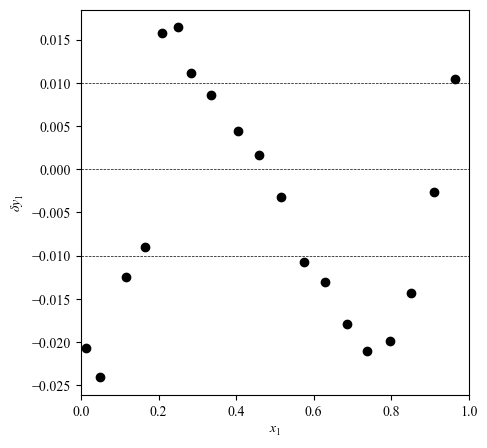

p/kPa = 50.01
N = 2
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.7092631697293268
A1 = 0.3608027486197595
A2 = 0.17084183976659556
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.22595452497826304
AAD(y1) = 0.005583481850538749
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.313382035425044
AAD(x1) = 0.012548131949457244
------------------------------------------


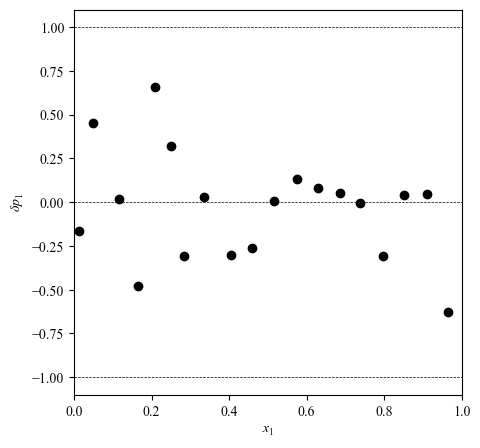

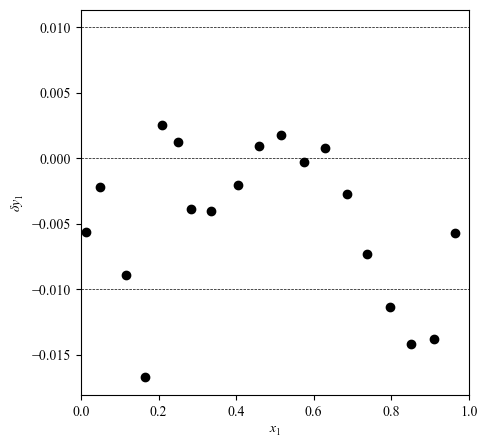

p/kPa = 50.01
N = 3
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.7105468733716676
A1 = 0.3802623289653076
A2 = 0.18101555846816486
A3 = 0.021379842065057362
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.23850286128517367
AAD(y1) = 0.005466573270184172
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.2865476048361503
AAD(x1) = 0.010620800940340713
------------------------------------------


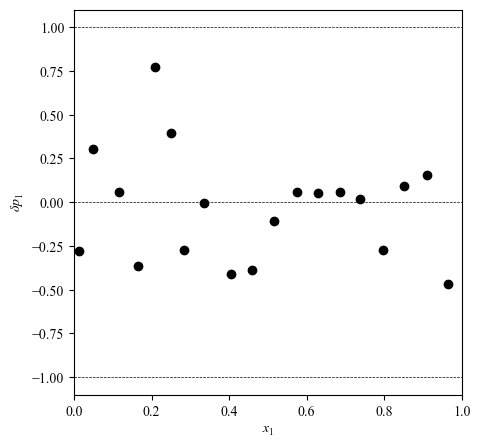

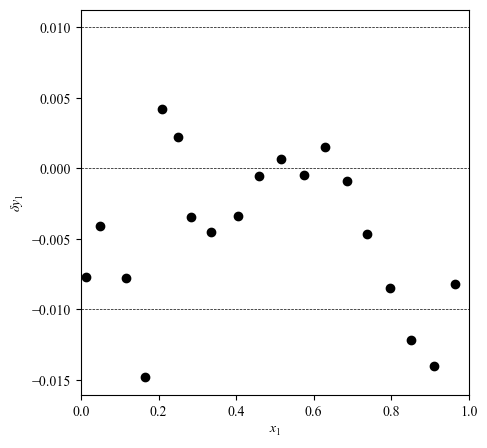

p/kPa = 50.01
N = 4
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.7184769803091615
A1 = 0.3862676324927584
A2 = 0.20700525653092156
A3 = 0.03243728789438974
A4 = 0.022117875903252853
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.228735927430214
AAD(y1) = 0.005078114119606478
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.27060182488286705
AAD(x1) = 0.00910587915803265
------------------------------------------


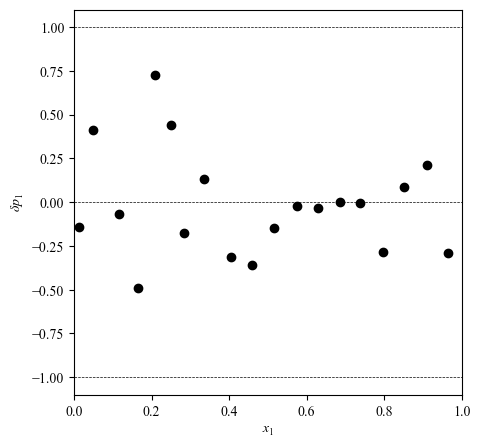

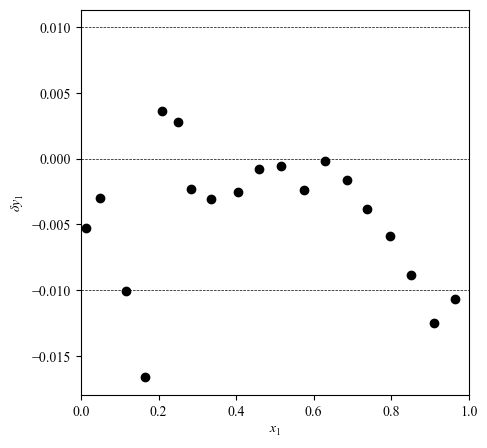

In [12]:
VLEgamphi(mix, "Legendre", "Ideal", Texp50, pexp50/100, Xexp50, Yexp50, A0=[1, 0, 0, 0, 0])

********************************************************************************
                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     
********************************************************************************
p/kPa = 75.01
N = 0
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6002871406206902
A1 = 0.0
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 2.2656987905665362
AAD(y1) = 0.02202063437345081
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 1.6288786540260294
AAD(x1) = 0.05936975641448887
------------------------------------------


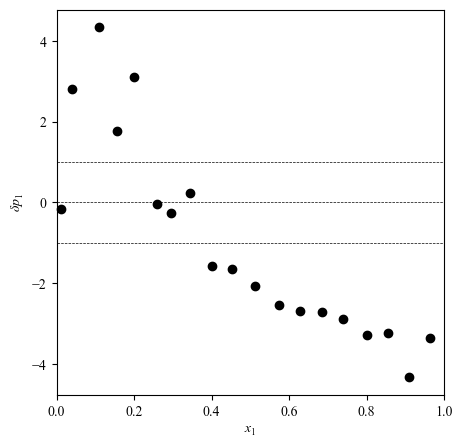

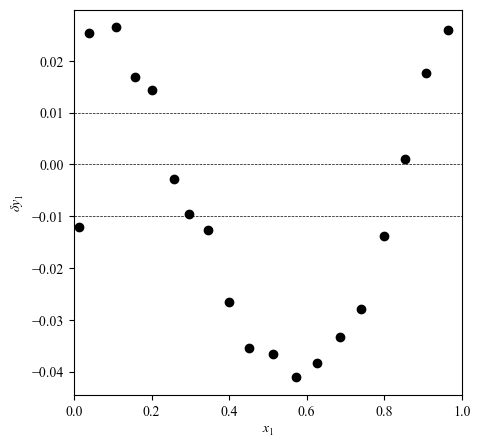

p/kPa = 75.01
N = 1
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6170940516149377
A1 = 0.2966984667368523
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.8341257180940213
AAD(y1) = 0.011249943839110566
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.7907013249457067
AAD(x1) = 0.030859428894658477
------------------------------------------


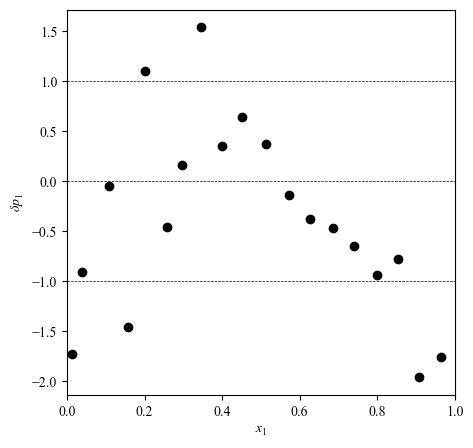

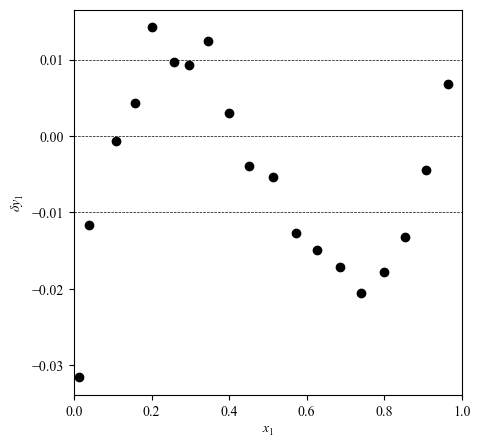

p/kPa = 75.01
N = 2
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6709055476560881
A1 = 0.3215038191202215
A2 = 0.12743170861089503
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.5768945875025275
AAD(y1) = 0.00618958557189527
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.5601783431648096
AAD(x1) = 0.01436501653943626
------------------------------------------


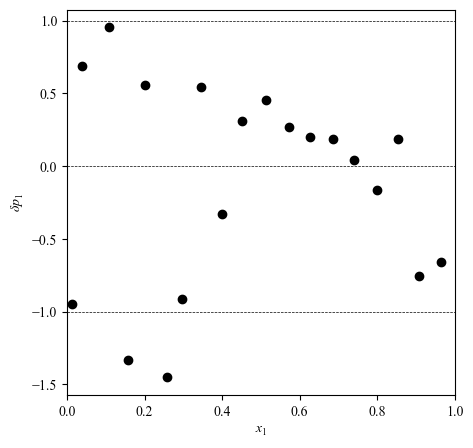

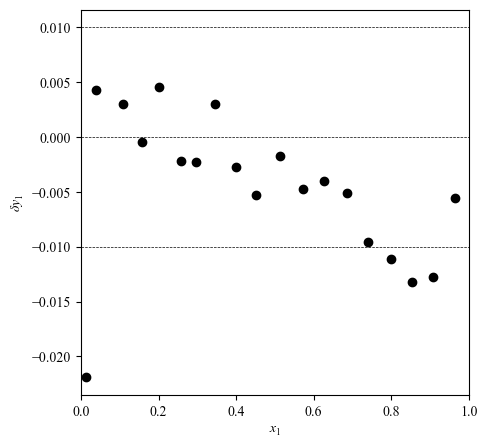

p/kPa = 75.01
N = 3
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6724305856988522
A1 = 0.3499734708745726
A2 = 0.13964854582511937
A3 = 0.030500857550982138
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.5049106899959434
AAD(y1) = 0.0060696813665291624
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.4930226100826963
AAD(x1) = 0.012223853407711772
------------------------------------------


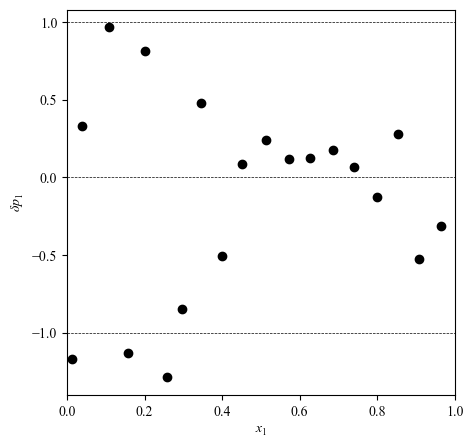

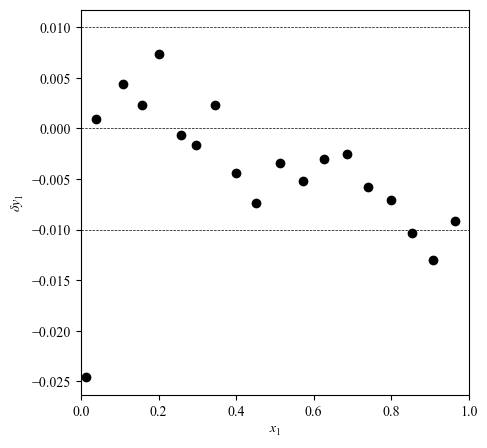

p/kPa = 75.01
N = 4
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6855590623034775
A1 = 0.35803833771838894
A2 = 0.18263494993703663
A3 = 0.04850548537799407
A4 = 0.0371357513948161
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.4567176462214927
AAD(y1) = 0.005696182343123812
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.47613343986110684
AAD(x1) = 0.012640232306234098
------------------------------------------


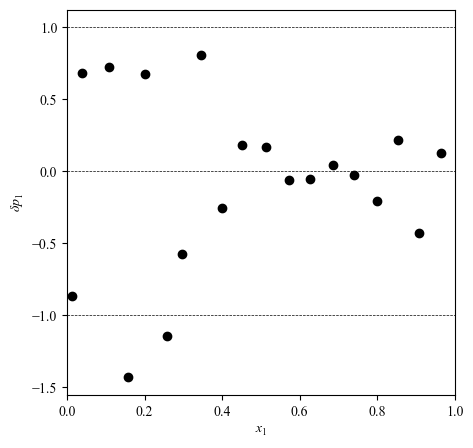

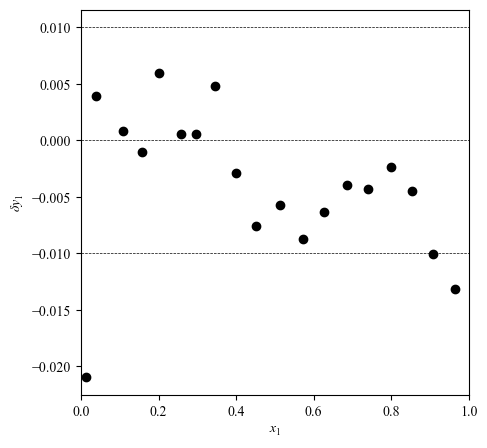

In [13]:
VLEgamphi(mix, "Legendre", "Ideal", Texp75, pexp75/100, Xexp75, Yexp75, A0=[1, 0, 0, 0, 0])

********************************************************************************
                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     
********************************************************************************
p/kPa = 94.01
N = 0
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.5915847887597032
A1 = 0.0
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 2.3969689075275737
AAD(y1) = 0.022025250725822045
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 1.9350296120409294
AAD(x1) = 0.057627871677222414
------------------------------------------


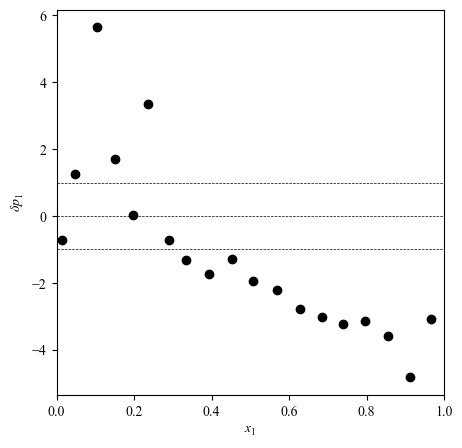

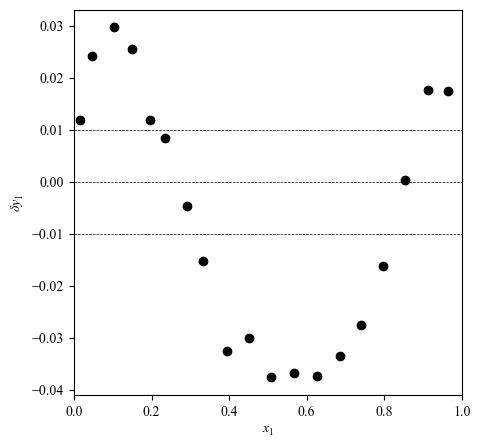

p/kPa = 94.01
N = 1
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6104662482006622
A1 = 0.25561560656209154
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 1.1430115593943029
AAD(y1) = 0.01059173069939711
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 1.4057308761199663
AAD(x1) = 0.030462866787644448
------------------------------------------


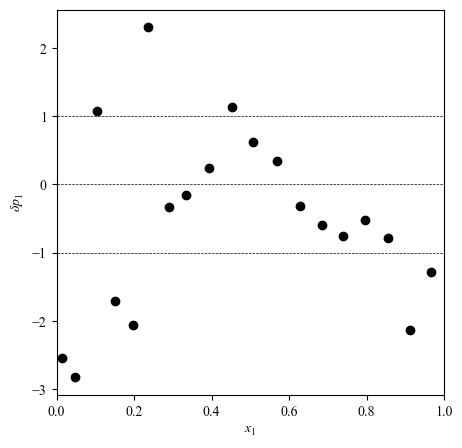

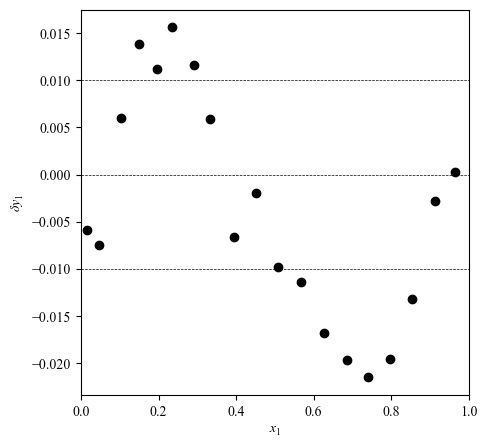

p/kPa = 94.01
N = 2
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6546105927728278
A1 = 0.2771376784130278
A2 = 0.10859369804306143
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.9168460652184082
AAD(y1) = 0.007477227957247291
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 1.1036727052858724
AAD(x1) = 0.01837412110045226
------------------------------------------


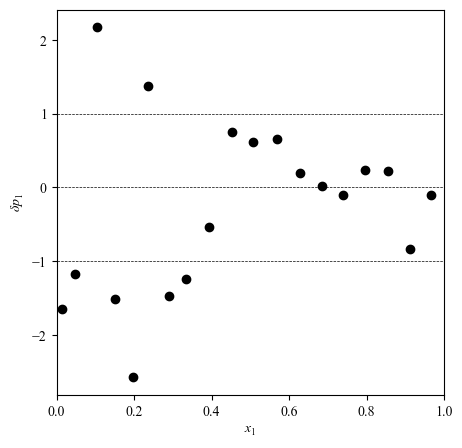

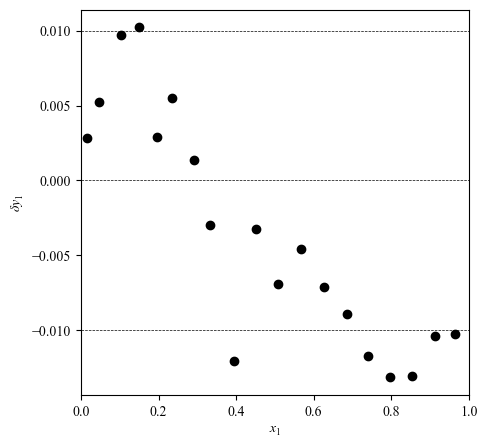

p/kPa = 94.01
N = 3
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6553611910521102
A1 = 0.29152509043513475
A2 = 0.11482095617975097
A3 = 0.016423160732660348
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.903097333864642
AAD(y1) = 0.007509819406404245
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 1.06618975078809
AAD(x1) = 0.017778811815161107
------------------------------------------


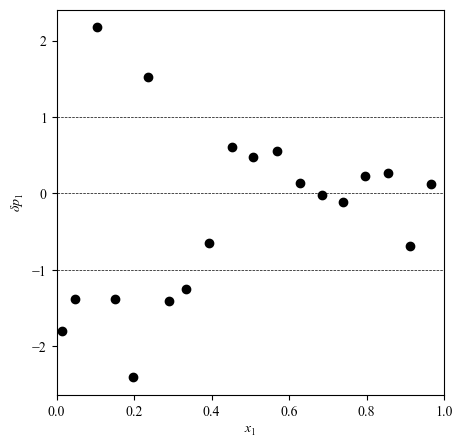

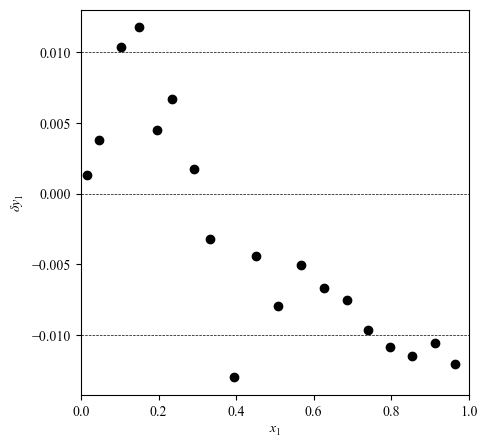

p/kPa = 94.01
N = 4
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 1.6700049380532467
A1 = 0.29884431759074725
A2 = 0.161128472015254
A3 = 0.03382836822309514
A4 = 0.04126855262525753
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.8344665551671056
AAD(y1) = 0.007265388771681938
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 1.0293697538790711
AAD(x1) = 0.017964892370923326
------------------------------------------


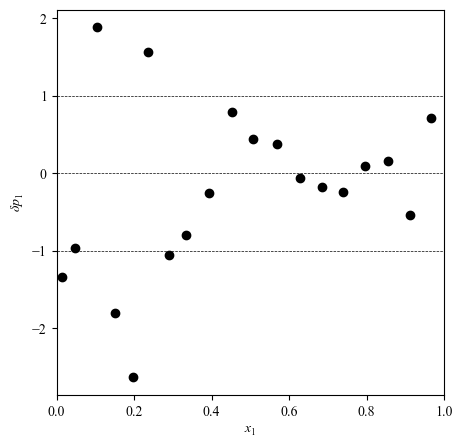

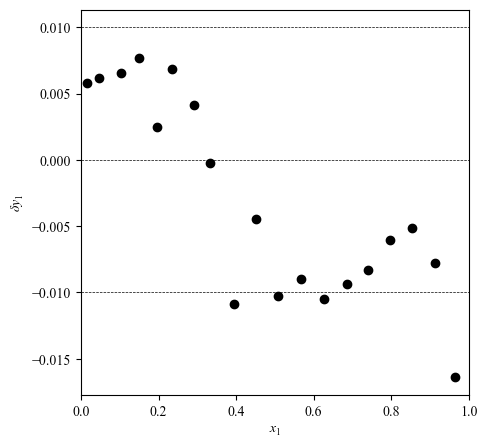

In [14]:
VLEgamphi(mix, "Legendre", "Ideal", Texp94, pexp94/100, Xexp94, Yexp94, A0=[1, 0, 0, 0, 0])

In [17]:
params50 = np.array([1.7184769808007962, 0.38626763586626034, 0.20700525764379962, 0.032437289699473675, 0.022117875350343732])
params75 = np.array([1.6855590601569796, 0.3580383339922357, 0.18263494195680455, 0.048505483414424407, 0.037135747674248085])
params94 = np.array([1.6700049448149112, 0.29884431816936124, 0.16112848601201837, 0.03382837104550947, 0.04126855964707602])

In [18]:
x1 = np.linspace(0.0, 1.0, num = 100)
z = len(x1)
#VLE calculations: 50.00 kPa
p = 50/100
T_50 = np.zeros(z)
y1_50 = np.zeros(z)
gE_50 = np.zeros(z)
gam1_50 = np.zeros(z)
gam2_50 = np.zeros(z)
for i in range(z):
    T_50[i], y1_50[i], gam1_50[i], gam2_50[i], gE_50[i] = Tybubble(mix, params50, "Legendre", "Ideal", p, x1[i], n=4, t0=[330])

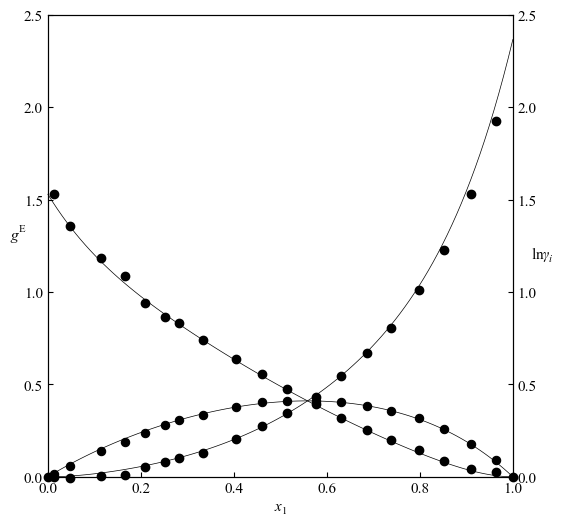

In [19]:
import matplotlib.pyplot as plt
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=11)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig, ax1 = plt.subplots(figsize=(6,6))
ax1.tick_params(direction='in')
ax1.set_xlabel(r'$x_{1}$')
ax1.set_ylabel(r'$g^{\mathrm{E}}$', rotation='horizontal')
ax1.scatter(Xexp50[0], exp50[2], color='black', linewidth=0.8)
ax1.plot(x1, gE_50, color='black', linewidth='0.5', clip_on=False, zorder=10)
ax1.set_ylim([0, 2.5])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.scatter(Xexp50[0], np.log(exp50[0]), color='black', clip_on=False, zorder=10)
ax2.scatter(Xexp50[0], np.log(exp50[1]), color='black', clip_on=False, zorder=10)
ax2.plot(x1, np.log(gam1_50), clip_on=False, color='black', linewidth='0.5', zorder=10)
ax2.plot(x1, np.log(gam2_50), clip_on=False, color='black', linewidth='0.5', zorder=10)
ax2.set_ylabel(r'$\mathrm{ln}\gamma_{i}$', rotation='horizontal')
ax2.set_ylim([0, 2.5])

plt.xlim([0, 1])
plt.savefig("leg50.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [20]:
#VLE calculations: 75.00 kPa
p = 75/100
T_75 = np.zeros(z)
y1_75 = np.zeros(z)
gE_75 = np.zeros(z)
gam1_75 = np.zeros(z)
gam2_75 = np.zeros(z)
for i in range(z):
    T_75[i], y1_75[i], gam1_75[i], gam2_75[i], gE_75[i] = Tybubble(mix, params75, "Legendre", "Ideal", p, x1[i], n=4, t0=[340])

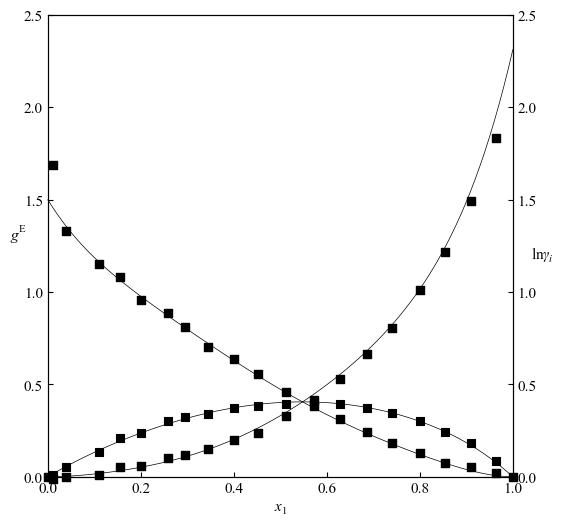

In [21]:
import matplotlib.pyplot as plt
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=11)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig, ax1 = plt.subplots(figsize=(6,6))
ax1.tick_params(direction='in')
ax1.set_xlabel(r'$x_{1}$')
ax1.set_ylabel(r'$g^{\mathrm{E}}$', rotation='horizontal')
ax1.scatter(Xexp75[0], exp75[2], marker='s', color='black', linewidth=0.8)
ax1.plot(x1, gE_75, color='black', linewidth='0.5', clip_on=False, zorder=10)
ax1.set_ylim([0, 2.5])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.scatter(Xexp75[0], np.log(exp75[0]), marker='s', color='black', clip_on=False, zorder=10)
ax2.scatter(Xexp75[0], np.log(exp75[1]), marker='s', color='black', clip_on=False, zorder=10)
ax2.plot(x1, np.log(gam1_75), clip_on=False, color='black', linewidth='0.5', zorder=10)
ax2.plot(x1, np.log(gam2_75), clip_on=False, color='black', linewidth='0.5', zorder=10)
ax2.set_ylabel(r'$\mathrm{ln}\gamma_{i}$', rotation='horizontal')
ax2.set_ylim([0, 2.5])

plt.xlim([0, 1])
plt.savefig("leg75.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [22]:
#VLE calculations: 94.00 kPa
p = 94/100
T_94 = np.zeros(z)
y1_94 = np.zeros(z)
gE_94 = np.zeros(z)
gam1_94 = np.zeros(z)
gam2_94 = np.zeros(z)
for i in range(z):
    T_94[i], y1_94[i], gam1_94[i], gam2_94[i], gE_94[i] = Tybubble(mix, params94, "Legendre", "Ideal", p, x1[i], n=4, t0=[340])

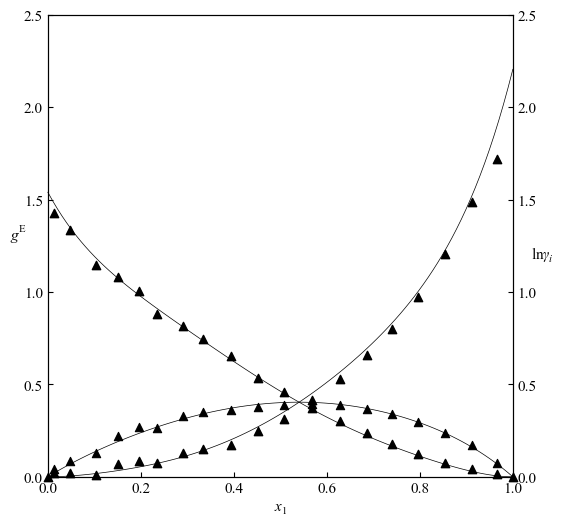

In [23]:
import matplotlib.pyplot as plt
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=11)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig, ax1 = plt.subplots(figsize=(6,6))
ax1.tick_params(direction='in')
ax1.set_xlabel(r'$x_{1}$')
ax1.set_ylabel(r'$g^{\mathrm{E}}$', rotation='horizontal')
ax1.scatter(Xexp94[0], exp94[2], marker='^', color='black', linewidth=0.8)
ax1.plot(x1, gE_94, color='black', linewidth='0.5', clip_on=False, zorder=10)
ax1.set_ylim([0, 2.5])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.scatter(Xexp94[0], np.log(exp94[0]), marker='^', color='black', clip_on=False, zorder=10)
ax2.scatter(Xexp94[0], np.log(exp94[1]), marker='^', color='black', clip_on=False, zorder=10)
ax2.plot(x1, np.log(gam1_94), clip_on=False, color='black', linewidth='0.5', zorder=10)
ax2.plot(x1, np.log(gam2_94), clip_on=False, color='black', linewidth='0.5', zorder=10)
ax2.set_ylabel(r'$\mathrm{ln}\gamma_{i}$', rotation='horizontal')
ax2.set_ylim([0, 2.5])

plt.xlim([0, 1])
plt.savefig("leg94.pdf", format="pdf", bbox_inches="tight")
plt.show()

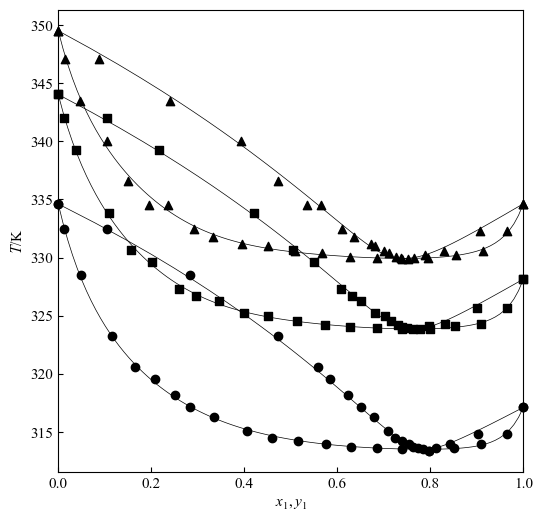

In [24]:
import matplotlib.pyplot as plt
plt.rc('text', usetex=False )
plt.rc('font', family="Times New Roman", weight='normal', size=11)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fig = plt.subplots(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], Texp50, color='black', clip_on=False, zorder=10)
plt.scatter(Yexp50[0], Texp50, color='black', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], Texp75, marker='s', color='black', clip_on=False, zorder=10)
plt.scatter(Yexp75[0], Texp75, marker='s', color='black', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], Texp94, marker='^', color='black', clip_on=False, zorder=10)
plt.scatter(Yexp94[0], Texp94, marker='^', color='black', clip_on=False, zorder=10)
plt.plot(x1, T_50, color='black', linewidth='0.5')
plt.plot(y1_50, T_50, color='black', linewidth='0.5')
plt.plot(x1, T_75, color='black', linewidth='0.5')
plt.plot(y1_75, T_75, color='black', linewidth='0.5')
plt.plot(x1, T_94, color='black', linewidth='0.5')
plt.plot(y1_94, T_94, color='black', linewidth='0.5')
plt.xlim([0, 1.0])
plt.xlabel(r'$x_{1}, y_{1}$')
plt.ylabel(r'$T$/K')
plt.savefig("VLE.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [15]:
VLEgamphi(mix, "Wilson", "Ideal", Texp50, pexp50/100, Xexp50, Yexp50, A0=[-100, 100, 0, 0, 0])
VLEgamphi(mix, "NRTL", "Ideal", Texp50, pexp50/100, Xexp50, Yexp50, A0=[-100, 100, 0, 0, 0])
VLEgamphi(mix, "UNIQUAC", "Ideal", Texp50, pexp50/100, Xexp50, Yexp50, A0=[100, 100, 0, 0, 0])

********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              
********************************************************************************
p/kPa = 50.01
Model = Wilson
Method = Ideal
------------------------------------------
Energy difference parameters:
------------------------------------------
de12 = 221.59941905889386
de21 = 467.0172620349686
------------------------------------------
Bubble-point calculations:
------------------------------------------
AAD(p)/kPa = 1.9535354164679206
AAD(y1) = 0.02175438207426411
------------------------------------------
Dew-point calculations:
------------------------------------------
AAD(p)/kPa = 1.5213682186041897
AAD(x1) = 0.06080033727541377
------------------------------------------
********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS         

In [16]:
VLEgamphi(mix, "Wilson", "Ideal", Texp75, pexp75/100, Xexp75, Yexp75, A0=[-100, 100, 0, 0, 0])
VLEgamphi(mix, "NRTL", "Ideal", Texp75, pexp75/100, Xexp75, Yexp75, A0=[-100, 100, 0, 0, 0])
VLEgamphi(mix, "UNIQUAC", "Ideal", Texp75, pexp75/100, Xexp75, Yexp75, A0=[100, 100, 0, 0, 0])

********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              
********************************************************************************
p/kPa = 75.01
Model = Wilson
Method = Ideal
------------------------------------------
Energy difference parameters:
------------------------------------------
de12 = 226.6355920692504
de21 = 475.6009751057814
------------------------------------------
Bubble-point calculations:
------------------------------------------
AAD(p)/kPa = 2.4084461689617256
AAD(y1) = 0.02317875685322467
------------------------------------------
Dew-point calculations:
------------------------------------------
AAD(p)/kPa = 1.6449867537593466
AAD(x1) = 0.060359588806407655
------------------------------------------
********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS         

In [17]:
VLEgamphi(mix, "Wilson", "Ideal", Texp94, pexp94/100, Xexp94, Yexp94, A0=[-100, 100, 0, 0, 0])
VLEgamphi(mix, "NRTL", "Ideal", Texp94, pexp94/100, Xexp94, Yexp94, A0=[-100, 100, 0, 0, 0])
VLEgamphi(mix, "UNIQUAC", "Ideal", Texp94, pexp94/100, Xexp94, Yexp94, A0=[100, 100, 0, 0, 0])

********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              
********************************************************************************
p/kPa = 94.01
Model = Wilson
Method = Ideal
------------------------------------------
Energy difference parameters:
------------------------------------------
de12 = 228.4937598477453
de21 = 479.3460879049551
------------------------------------------
Bubble-point calculations:
------------------------------------------
AAD(p)/kPa = 2.5538339735007427
AAD(y1) = 0.023413322511853532
------------------------------------------
Dew-point calculations:
------------------------------------------
AAD(p)/kPa = 1.770409945376715
AAD(x1) = 0.056902277536997996
------------------------------------------
********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS         